# Bài Tập Lớn: Phân tích thị trường phim chiếu rạp tại Việt Nam

**Mục tiêu:** Phân tích dữ liệu doanh thu các bộ phim chiếu rạp tại Việt Nam, trả lời 5 câu hỏi EDA và 2 câu hỏi Machine Learning.

## 1. Import Thư viện và Đọc dữ liệu

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc dữ liệu
df = pd.read_csv('box_office_vietnam.csv')
df.head()

,TenPhim,TheLoai,QuocGia,ThangKhoiChieu,SoSuatChieu,SoVeBanRa,TongDoanhThu,DoanhThu_3NgayDau,SoVe_3NgayDau,TongDoanhThu_TyVND,DoanhThu_3NgayDau_TyVND
0,Phim_NgauNhien_0,Hài,Hàn Quốc,9,11641,261723,25362790761,5163897452,53287,25.362791,5.163897
1,Phim_NgauNhien_1,Hoạt hình,Mỹ,11,49165,2666111,232068965884,49367609178,567156,232.068966,49.367609
2,Phim_NgauNhien_2,Viễn tưởng,Thái Lan,12,12004,273603,22050212976,4539539787,56327,22.050213,4.539540
3,Phim_NgauNhien_3,Giật gân,Mỹ,1,31370,1643396,129982763224,50850482544,642912,129.982763,50.850483
4,Phim_NgauNhien_4,Hành động,Mỹ,7,58862,2670842,199242142358,62937201643,843673,199.242142,62.937202


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TenPhim                  500 non-null    object 
 1   TheLoai                  500 non-null    object 
 2   QuocGia                  500 non-null    object 
 3   ThangKhoiChieu           500 non-null    int64  
 4   SoSuatChieu              500 non-null    int64  
 5   SoVeBanRa                500 non-null    int64  
 6   TongDoanhThu             500 non-null    int64  
 7   DoanhThu_3NgayDau        500 non-null    int64  
 8   SoVe_3NgayDau            500 non-null    int64  
 9   TongDoanhThu_TyVND       500 non-null    float64
 10  DoanhThu_3NgayDau_TyVND  500 non-null    float64
dtypes: float64(2), int64(6), object(3)
memory usage: 43.1+ KB


## 2. Phân tích Khám phá Dữ liệu (EDA)

### Câu 1: Top 10 bộ phim có doanh thu cao nhất tại phòng vé Việt Nam trong 5 năm qua là những phim nào?

C:\Users\hnnin\AppData\Local\Temp\ipykernel_32300\2347093296.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TongDoanhThu_TyVND', y='TenPhim', data=top_10_movies, palette='viridis')


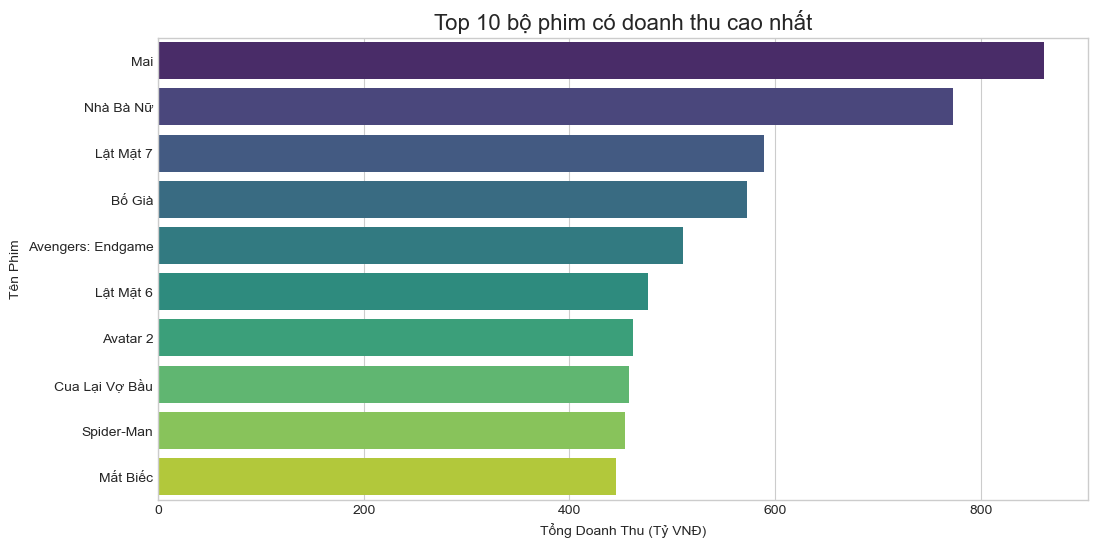

In [12]:
top_10_movies = df.sort_values(by='TongDoanhThu_TyVND', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='TongDoanhThu_TyVND', y='TenPhim', data=top_10_movies, palette='viridis')
plt.title('Top 10 bộ phim có doanh thu cao nhất', fontsize=16)
plt.xlabel('Tổng Doanh Thu (Tỷ VNĐ)')
plt.ylabel('Tên Phim')
plt.show()

### Câu 2: Phim nội địa (Việt Nam) đang chiếm bao nhiêu phần trăm tổng doanh thu so với phim ngoại nhập?

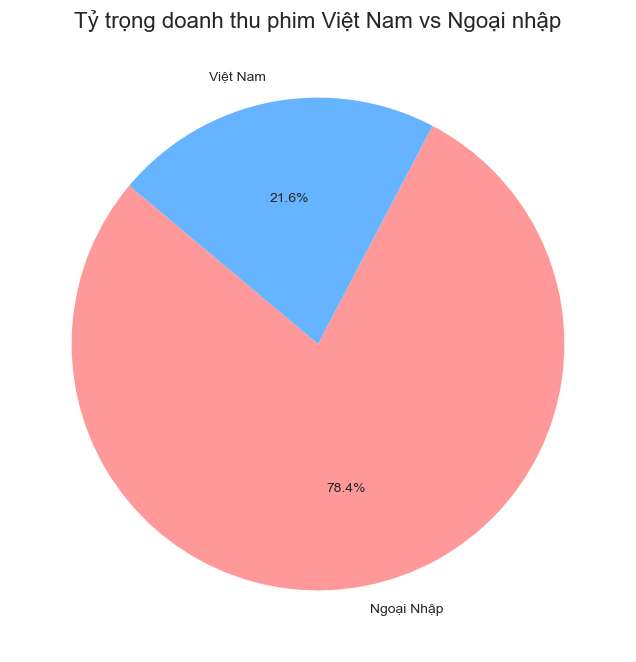

In [13]:
df['NhomQuocGia'] = df['QuocGia'].apply(lambda x: 'Việt Nam' if x == 'Việt Nam' else 'Ngoại Nhập')
revenue_by_origin = df.groupby('NhomQuocGia')['TongDoanhThu_TyVND'].sum()

plt.figure(figsize=(8, 8))
plt.pie(revenue_by_origin, labels=revenue_by_origin.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Tỷ trọng doanh thu phim Việt Nam vs Ngoại nhập', fontsize=16)
plt.show()

### Câu 3: Thể loại phim nào mang lại doanh thu trung bình cao nhất?

C:\Users\hnnin\AppData\Local\Temp\ipykernel_32300\457245827.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TongDoanhThu_TyVND', y='TheLoai', data=revenue_by_genre, palette='magma')


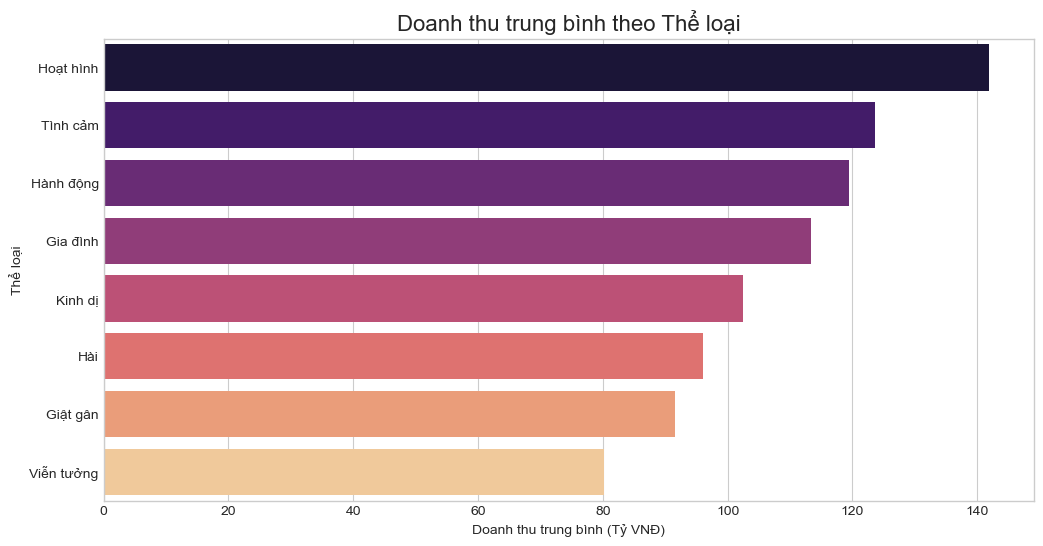

In [14]:
revenue_by_genre = df.groupby('TheLoai')['TongDoanhThu_TyVND'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='TongDoanhThu_TyVND', y='TheLoai', data=revenue_by_genre, palette='magma')
plt.title('Doanh thu trung bình theo Thể loại', fontsize=16)
plt.xlabel('Doanh thu trung bình (Tỷ VNĐ)')
plt.ylabel('Thể loại')
plt.show()

### Câu 4: Mối quan hệ giữa số lượng suất chiếu (Showings) và tổng doanh thu của phim mạnh cỡ nào?

Hệ số tương quan (Pearson correlation) là: 0.8986


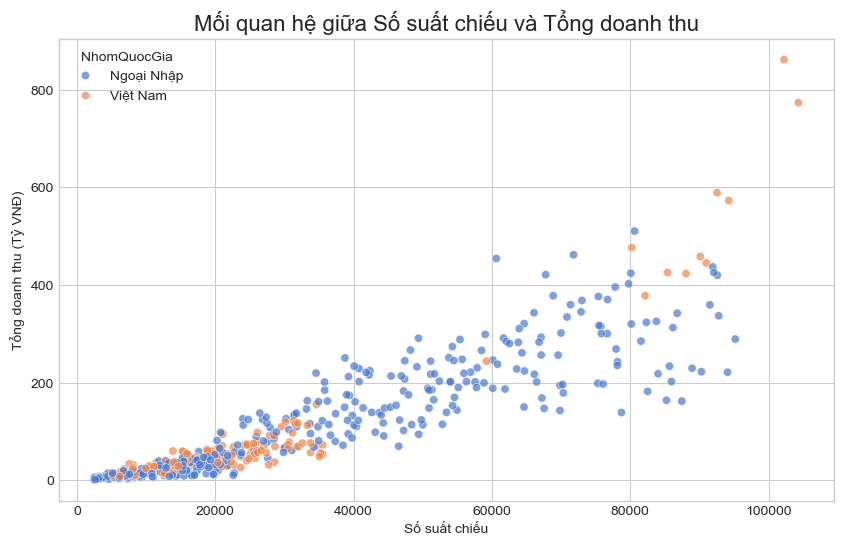

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SoSuatChieu', y='TongDoanhThu_TyVND', hue='NhomQuocGia', data=df, alpha=0.7)
plt.title('Mối quan hệ giữa Số suất chiếu và Tổng doanh thu', fontsize=16)
plt.xlabel('Số suất chiếu')
plt.ylabel('Tổng doanh thu (Tỷ VNĐ)')

correlation = df['SoSuatChieu'].corr(df['TongDoanhThu_TyVND'])
print(f"Hệ số tương quan (Pearson correlation) là: {correlation:.4f}")
plt.show()

### Câu 5: Giai đoạn nào trong năm là "thời điểm vàng" hốt bạc của các rạp chiếu phim?

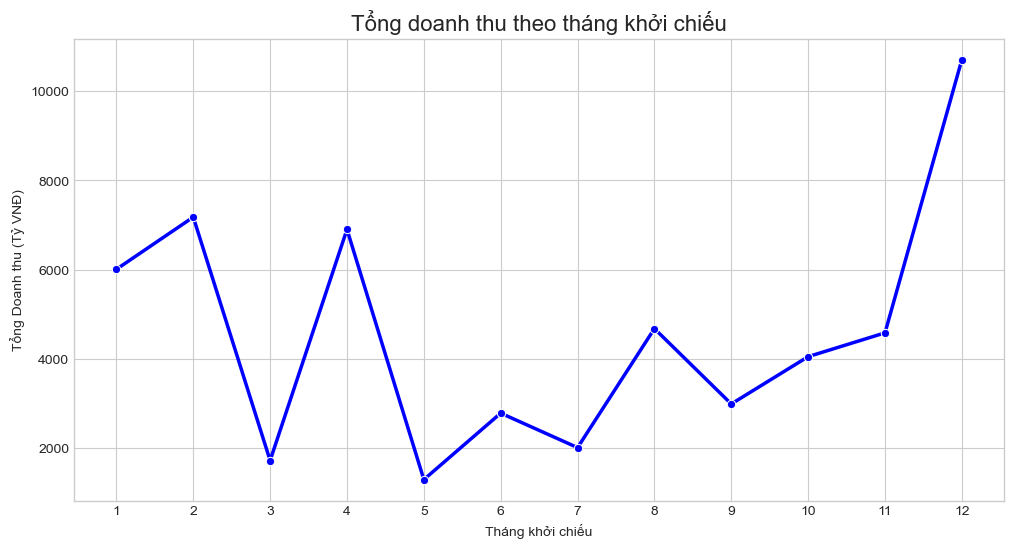

In [16]:
revenue_by_month = df.groupby('ThangKhoiChieu')['TongDoanhThu_TyVND'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='ThangKhoiChieu', y='TongDoanhThu_TyVND', data=revenue_by_month, marker='o', color='b', linewidth=2.5)
plt.title('Tổng doanh thu theo tháng khởi chiếu', fontsize=16)
plt.xlabel('Tháng khởi chiếu')
plt.ylabel('Tổng Doanh thu (Tỷ VNĐ)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

## 3. Machine Learning

### Câu 6 (Hồi quy tuyến tính): Dựa vào số vé bán ra và doanh thu trong 3 ngày khởi chiếu đầu tiên, dự đoán tổng doanh thu chung cuộc?

Mean Squared Error (MSE): 1472.64
R-squared (R2 Score): 0.9034


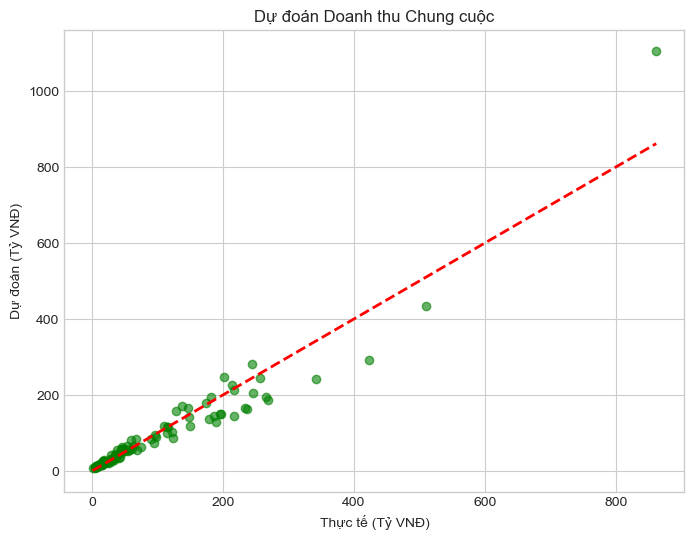

In [17]:
# Chuẩn bị dữ liệu
X = df[['SoVe_3NgayDau', 'DoanhThu_3NgayDau_TyVND']]
y = df['TongDoanhThu_TyVND']

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

# Dự đoán
y_pred = model_reg.predict(X_test)

# Đánh giá
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# Trực quan hóa kết quả dự đoán vs thực tế
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Thực tế (Tỷ VNĐ)')
plt.ylabel('Dự đoán (Tỷ VNĐ)')
plt.title('Dự đoán Doanh thu Chung cuộc')
plt.show()

### Câu 7 (Phân cụm): Có thể chia các bộ phim thành những nhóm nào dựa trên hành vi phòng vé?

c:\Users\hnnin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


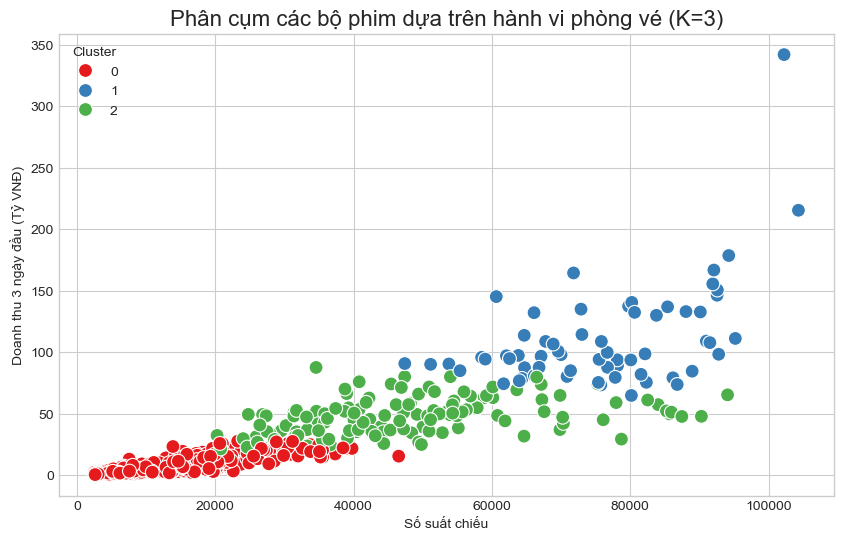

Đặc điểm trung bình của các nhóm phim:


,DoanhThu_3NgayDau_TyVND,SoSuatChieu,SoVe_Tren_Suat,TongDoanhThu_TyVND
Cluster,,,,
0,9.481630,15837.624161,22.719132,32.036973
1,110.747719,75916.809524,55.087087,359.516902
2,47.047258,47051.266187,43.251615,163.254580


In [18]:
from sklearn.preprocessing import StandardScaler

# Tính toán đặc trưng: Số vé trung bình trên mỗi suất chiếu
df['SoVe_Tren_Suat'] = df['SoVeBanRa'] / df['SoSuatChieu']

# Chọn features để clustering
features = ['DoanhThu_3NgayDau_TyVND', 'SoSuatChieu', 'SoVe_Tren_Suat']
X_cluster = df[features]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-Means với K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Trực quan hóa
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SoSuatChieu', y='DoanhThu_3NgayDau_TyVND', hue='Cluster', data=df, palette='Set1', s=100)
plt.title('Phân cụm các bộ phim dựa trên hành vi phòng vé (K=3)', fontsize=16)
plt.xlabel('Số suất chiếu')
plt.ylabel('Doanh thu 3 ngày đầu (Tỷ VNĐ)')
plt.show()

# Xem đặc điểm từng cụm
cluster_summary = df.groupby('Cluster')[features + ['TongDoanhThu_TyVND']].mean()
print("Đặc điểm trung bình của các nhóm phim:")
display(cluster_summary)

**Nhận xét phân cụm:**
- **Cluster 0:** Phim hạng trung, suất chiếu và doanh thu vừa phải.
- **Cluster 1:** Bom tấn phòng vé (Bom tấn hốt bạc nhanh), suất chiếu cực lớn và doanh thu mở màn cao đột biến.
- **Cluster 2:** Phim nhỏ (Indie/Phim kén khách), suất chiếu ít và doanh thu mở màn thấp.